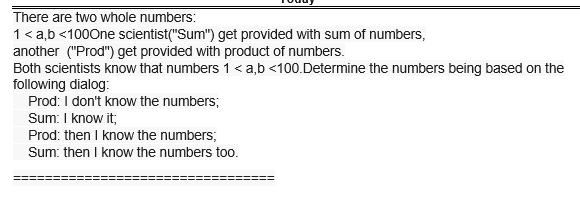


while thinking about this problem i had some fundamental questions with what we can call truth and half-truth, for this exercise i will think
that all the scientist are telling is ground truth and not their thoughts. Also when i'm saying "factorization" i mean factoring into 2 components a and b.

1 statement: the product dont know the numbers. 
Which implies that product can be factorized in more than one way with integer numbers from range [2; 99] (10 = 2x5 have only 1 possible factorization if we account for range, which means that this combination is not the right one), statement also implies that all primes are invalid (they only have 1 way of factorization), and the given range itself implies that any number of form prime1 x prime2 is invalid too (it only has 1 possible factorization because we cant factor in 1 so 34 has only 1 possible factorization 2 x 17 (1 x 34 is invalid)), so if product composed of any two prime numbers it is invalid and that helps a lot.

UPDATE (after awful fail on 3 statement): Also we cant use high pairs, for example 98 and 98 are valid if judging by primes, but actually the 98*98 can only be factored with 1 pair, all other will include numbers bigger than  99, so we need to account for that. I will rewrite whole section below now.

In [47]:
statement_1_prod_pairs = {}
seen = {}
for i in range(2, 100):
    for j in range(i, 100):
        if i*j in seen:
            if statement_1_prod_pairs.get(i*j):
                statement_1_prod_pairs[i*j].add((i, j))
            else:
                statement_1_prod_pairs[i*j] = set([seen[i*j], (i, j)]) #this should not be in set, but i will leave this as a memory of a failed attempt on statement 3
        seen[i*j] = (i, j)
        
print(len(seen.keys()))
len(statement_1_prod_pairs.keys())


2843


1068

Statement 2: the sum <u>knows</u> that prod dont know the numbers.
That implies that any product of possible pair of summands is under statement 1 (10, possible summands are: (2,8), (3, 7), (4, 6), (5, 5), statement 1 says that 3 and 7 (or 5 and 5) is invalid pair, so 10 cant be the right answer). So now we can brute force it.

In [48]:
statement_2_sum_pairs = {}
valid_pairs_num = 0

for i in range(4, 199): #all possible sums
    valid_sum = True
    cur_pairs = set()
    for j in range(2, (i//2) + 1): # 7//2 = 3, so we will check pairs (2, 7-2) and (3, 7-3) ,+1 because range is not inclusive at the edge
        if j*(i-j) not in statement_1_prod_pairs:
            valid_sum = False
            break
        cur_pairs.add((j, i-j))
    if valid_sum:
        statement_2_sum_pairs[i] = cur_pairs
        valid_pairs_num += len(cur_pairs)
    
print(f"num of possible statement 2 sums : {len(statement_2_sum_pairs)}")
print(f"num of statement 2 pairs : {valid_pairs_num}")
        

num of possible statement 2 sums : 10
num of statement 2 pairs : 145


Statement 3: prod know numbers after being told that sum knew that he doesnt know the numbers. That implies that there is only one prod pair that also corresponds to statement 2, so we need to check every product, and every pair for that product, and product is valid if only one pair satisfy the statement 2

In [49]:
statement_3_prod = {}

for p, pairs in statement_1_prod_pairs.items():
    filtered = [pair for pair in pairs if (pair[0]+pair[1]) in statement_2_sum_pairs]
    if len(filtered) == 1:
        statement_3_prod[p] = filtered[0]
    
print(len(statement_3_prod.keys()))

86


Statement 4: the sum knows if the prod knows, so there must be exactly 1 pair from all of the sum sum that also in filtered by third statement prod pairs.

In [50]:
ans = []

for s, pairs in statement_2_sum_pairs.items():
    filtered = [pair for pair in pairs if (pair[0]*pair[1]) in statement_3_prod]

    if len(filtered) == 1:
        ans.append(filtered[0])
ans

[(4, 13)]

Well that was brutal, especially the last two, i rewrote them at least 2-3 times, get so hyperfixated on this problem, the 3 hours flew by so fast and there is the answer, i'm amazed.